In [96]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings("ignore")


In [97]:
# Đọc dữ liệu từ file csv
merged_df = pd.read_csv("../DATA EXPLORER CONTEST/Preprocessed_Data/merged_data_(t-1).csv")

In [103]:
# --- Lấy các cột cần thiết ---
features = ['EPS','P/E','P/B','P/S',
            'Loi nhuan','Market Cap_lag1',
            'Foreign Investor Room_lag1','Remaining Room Shares_lag1']
target = 'Closing Price'

# XGBoost

In [104]:
from xgboost import XGBRegressor

In [105]:
# --- Tách tập train/test (80/20 theo thời gian) ---
split_index = int(len(merged_df) * 0.8)
train_df = merged_df.iloc[:split_index]
test_df = merged_df.iloc[split_index:]

X_train_raw = train_df[features]
y_train = train_df[target]

X_test_raw = test_df[features]
y_test = test_df[target]

# --- Chuẩn hóa dữ liệu ---
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

# --- Huấn luyện mô hình XGBoost ---
model = XGBRegressor(n_estimators=100, max_depth=4, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)

# --- Dự đoán ---
y_pred = model.predict(X_test)

# --- Đánh giá mô hình ---
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"📊 Mean Squared Error (MSE): {mse:.2f}")
print(f"📊 RMSE: {rmse:.2f}")
print(f"📊 Mean Absolute Error (MAE): {mae:.2f}")
print(f"📈 R² Score: {r2:.4f}")

📊 Mean Squared Error (MSE): 9873861.00
📊 RMSE: 3142.27
📊 Mean Absolute Error (MAE): 2498.46
📈 R² Score: 0.4805


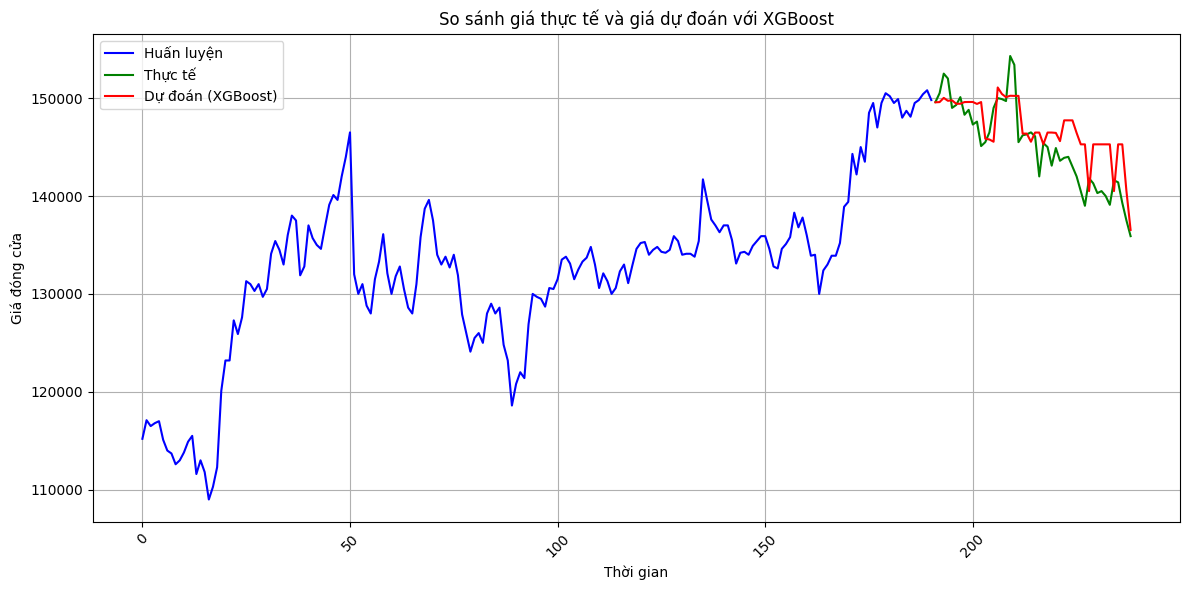

In [106]:
# Tạo DataFrame để trực quan
train_index = X_train_raw.index
test_index = X_test_raw.index

train_df_plot = pd.DataFrame({'Giá huấn luyện': y_train}, index=train_index)
test_df_plot = pd.DataFrame({'Giá thực tế': y_test, 'Giá dự đoán': y_pred}, index=test_index)

# Vẽ biểu đồ
plt.figure(figsize=(12, 6))
plt.plot(train_df_plot.index, train_df_plot['Giá huấn luyện'], label='Huấn luyện', color='blue')
plt.plot(test_df_plot.index, test_df_plot['Giá thực tế'], label='Thực tế', color='green')
plt.plot(test_df_plot.index, test_df_plot['Giá dự đoán'], label='Dự đoán (XGBoost)', color='red')

plt.title('So sánh giá thực tế và giá dự đoán với XGBoost')
plt.xlabel('Thời gian')
plt.ylabel('Giá đóng cửa')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()